In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

In [3]:
csv_path = "BTC-USD.csv"   
df = pd.read_csv(csv_path, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [5]:
values = df["Close"].astype("float32").values.reshape(-1, 1)


In [7]:
n = len(values)
n_train = int(0.7 * n)
n_val   = int(0.1 * n)
train, val, test = values[:n_train], values[n_train:n_train+n_val], values[n_train+n_val:]


In [9]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)
test_scaled  = scaler.transform(test)


In [11]:
SEQ_LEN = 100
def make_windows(x_scaled, seq_len):
    X, y = [], []
    for i in range(len(x_scaled) - seq_len):
        X.append(x_scaled[i:i+seq_len-1])   # history
        y.append(x_scaled[i+seq_len-1])     # next step (1-step ahead)
    return np.array(X), np.array(y)


In [13]:
X_train, y_train = make_windows(train_scaled, SEQ_LEN)
X_val,   y_val   = make_windows(val_scaled,   SEQ_LEN)
X_test,  y_test  = make_windows(test_scaled,  SEQ_LEN)


In [15]:
print(X_train.shape, y_train.shape, " | ", X_test.shape, y_test.shape)


(1913, 99, 1) (1913, 1)  |  (477, 99, 1) (477, 1)


In [17]:
DROPOUT = 0.2
WINDOW_SIZE = SEQ_LEN - 1


In [19]:
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

In [21]:
model = Sequential([
    Input(shape=(100, 1)),             # 👈 recommended
    LSTM(128),
    Dense(1, activation='sigmoid')
])

In [23]:
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="mse",
              metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
                       keras.metrics.MeanAbsolutePercentageError(name="mape")])


In [25]:
cb = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4)
]

In [27]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=32,
    shuffle=False,   # important for sequences
    callbacks=cb,
    verbose=2
)

Epoch 1/8
60/60 - 7s - 114ms/step - loss: 0.1200 - mae: 0.2817 - mape: 263679.4062 - val_loss: 0.5552 - val_mae: 0.7035 - val_mape: 99.9830 - learning_rate: 0.0010
Epoch 2/8
60/60 - 3s - 48ms/step - loss: 0.0846 - mae: 0.2042 - mape: 155.6603 - val_loss: 0.5353 - val_mae: 0.6893 - val_mape: 97.7822 - learning_rate: 0.0010
Epoch 3/8
60/60 - 2s - 39ms/step - loss: 0.0362 - mae: 0.1215 - mape: 7200.4321 - val_loss: 0.1697 - val_mae: 0.3351 - val_mape: 42.7413 - learning_rate: 0.0010
Epoch 4/8
60/60 - 2s - 39ms/step - loss: 0.0706 - mae: 0.2154 - mape: 185018.8438 - val_loss: 0.2577 - val_mae: 0.4488 - val_mape: 60.5777 - learning_rate: 0.0010
Epoch 5/8
60/60 - 2s - 40ms/step - loss: 0.0566 - mae: 0.1997 - mape: 122364.1016 - val_loss: 0.2336 - val_mae: 0.4228 - val_mape: 56.6238 - learning_rate: 0.0010
Epoch 6/8
60/60 - 3s - 53ms/step - loss: 0.0523 - mae: 0.1931 - mape: 131726.9219 - val_loss: 0.1297 - val_mae: 0.2956 - val_mape: 37.9121 - learning_rate: 0.0010
Epoch 7/8
60/60 - 3s - 51m

In [29]:
test_loss, test_mae, test_mape = model.evaluate(X_test, y_test, verbose=0)
print(f"[TEST] MSE={test_loss:.6f}  MAE={test_mae:.6f}  MAPE={test_mape:.2f}%")


[TEST] MSE=1.691460  MAE=1.160284  MAPE=49.53%


In [31]:
y_hat = model.predict(X_test, verbose=0)

y_test_inv = scaler.inverse_transform(y_test)
y_hat_inv  = scaler.inverse_transform(y_hat)


In [33]:
rmse = np.sqrt(np.mean((y_hat_inv - y_test_inv)**2))
mae  = np.mean(np.abs(y_hat_inv - y_test_inv))
print(f"[TEST] RMSE (₹/$/unit)={rmse:.2f}  MAE={mae:.2f}")


[TEST] RMSE (₹/$/unit)=25125.93  MAE=22415.87


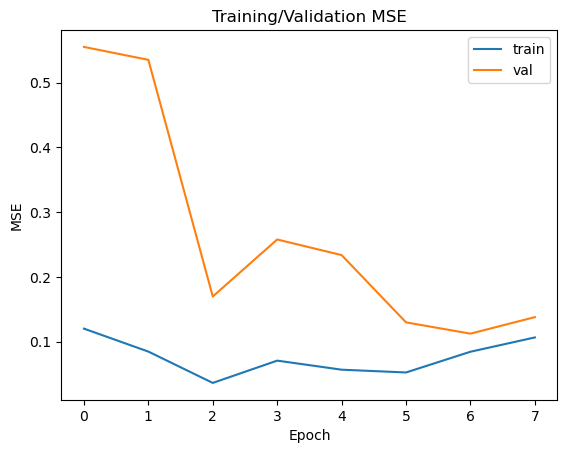

In [35]:
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Training/Validation MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()


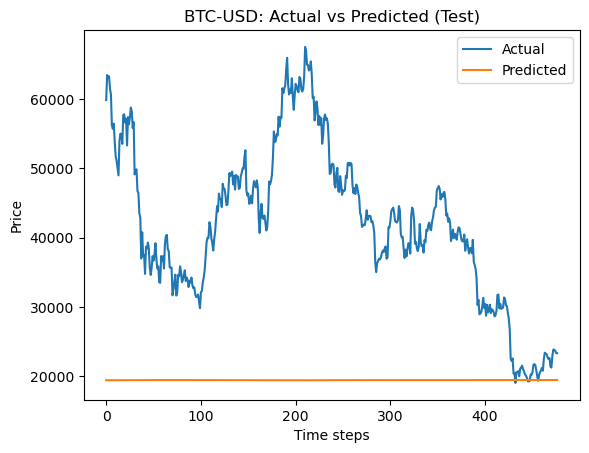

In [37]:
plt.figure()
plt.plot(y_test_inv, label="Actual")
plt.plot(y_hat_inv, label="Predicted")
plt.title("BTC-USD: Actual vs Predicted (Test)")
plt.xlabel("Time steps"); plt.ylabel("Price"); plt.legend(); plt.show()


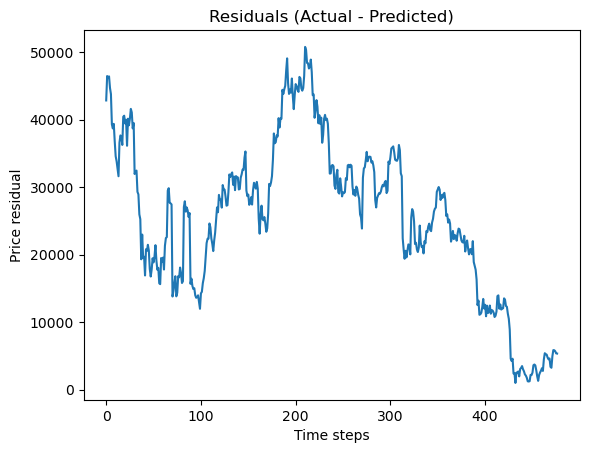

In [51]:
resid = (y_test_inv - y_hat_inv).squeeze()
plt.figure()
plt.plot(resid)
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Time steps"); plt.ylabel("Price residual")
plt.show()